In [4]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "lora_playground").exists():
    ROOT = ROOT.parent

DEFAULT_LOGS = [
    ROOT / "logs/bench_ssc_drift/v5_bs32_kpar_split_K3_R5W5_n10eval20_h10_p2_r256_lr3e-2_100_DIAG_ema0p8_warmreset.log",
    ROOT / "logs/bench_ssc_drift/debug_bs32_kpar_K3R5_p2_nan_trace_2k.log",
    ROOT / "logs/bench_ssc_drift/debug_bs32_kpar_K3R5_p2_nan_window.log",
]
LOGS = [p for p in DEFAULT_LOGS if p.exists()]

POLICY_CSV = ROOT / "notebooks/snapshot_analysis/_data/ssc_adaptive_c_policy_candidates.csv"
CACHE_CSV = ROOT / "notebooks/snapshot_analysis/_data/ssc_kpar_cache_policy_candidates.csv"
FAIL_CSV = ROOT / "notebooks/snapshot_analysis/_data/ssc_failing_snapshot_policy_candidates.csv"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


def read_events(paths):
    rows = []
    for path in paths:
        with path.open() as fh:
            for line in fh:
                try:
                    obj = json.loads(line)
                except json.JSONDecodeError:
                    continue
                obj["source"] = path.name
                rows.append(obj)
    return rows


events = read_events(LOGS)
agg = pd.DataFrame([e for e in events if e.get("event") == "ssc_c_diag"])

print(f"Loaded {len(events)} JSONL events from {len(LOGS)} log file(s).")
for path in LOGS:
    print(path.relative_to(ROOT))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 5931 JSONL events from 2 log file(s).
logs/bench_ssc_drift/v5_bs32_kpar_split_K3_R5W5_n10eval20_h10_p2_r256_lr3e-2_100_DIAG_ema0p8_warmreset.log
logs/bench_ssc_drift/debug_bs32_kpar_K3R5_p2_nan_trace_2k.log


## What is being compared

This notebook has two separate jobs.

First, it checks the existing kpar diagnostic logs. In those plots, **true c** means the exact eigvalsh solve for the requested target $\kappa=0.6$, while **kpar c** means the c actually used by the approximate kpar path.

Second, it compares offline policy candidates on saved optimizer snapshots. The candidate names mean:

- **exact per-layer c**: solve $c$ independently for each layer/pair using eigvalsh and target $\kappa=0.6$. This is the oracle reference, not the cheap path.
- **bulk per-layer c**: compute $c$ independently for each layer from the normalized-stable-rank one-spike-plus-flat-tail approximation.
- **exact group median c**: compute exact per-layer c values inside one shape group, take their median, and apply that one scalar to every layer in that group. The plotted error is exactly the mismatch caused by replacing per-layer c with this shared median.
- **bulk group median c**: same shared-median policy, but the median is taken over bulk per-layer c values rather than exact eigvalsh values.

The policy plots are offline diagnostics. They test whether candidate c values look numerically sane relative to exact eigvalsh c; they do not test training loss.


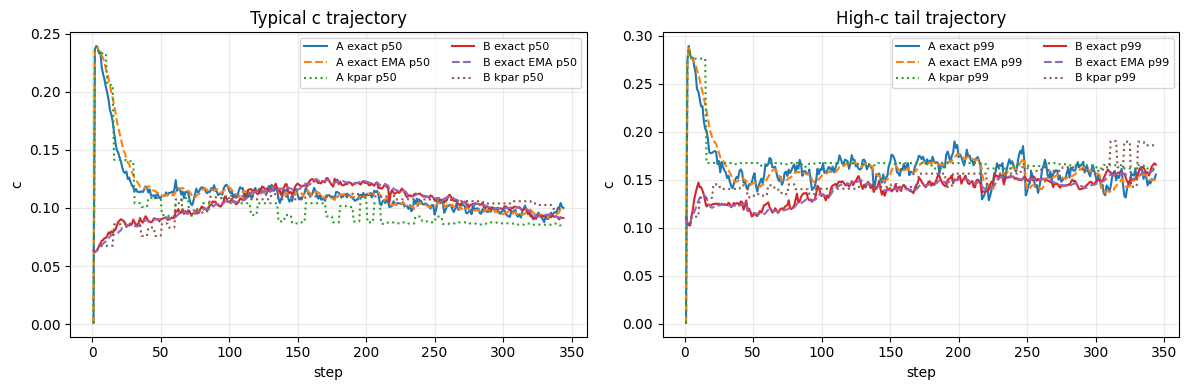

In [5]:
if agg.empty:
    fig, ax = plt.subplots(figsize=(8, 2.6))
    ax.text(0.5, 0.5, "No ssc_c_diag records found", ha="center", va="center")
    ax.set_axis_off()
else:
    for col in ("step", "n"):
        agg[col] = pd.to_numeric(agg[col], errors="coerce")
    plot_df = agg[(agg["step"] >= 1) & (agg["n"] == agg["n"].max())].copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    for side, sub in plot_df.groupby("side"):
        by_step = sub.groupby("step", as_index=False)[[
            "c_true_p50", "c_true_p99", "c_ema_p50", "c_ema_p99", "c_used_p50", "c_used_p99"
        ]].median(numeric_only=True)
        axes[0].plot(by_step["step"], by_step["c_true_p50"], label=f"{side} exact p50")
        axes[0].plot(by_step["step"], by_step["c_ema_p50"], ls="--", label=f"{side} exact EMA p50")
        axes[0].plot(by_step["step"], by_step["c_used_p50"], ls=":", label=f"{side} kpar p50")
        axes[1].plot(by_step["step"], by_step["c_true_p99"], label=f"{side} exact p99")
        axes[1].plot(by_step["step"], by_step["c_ema_p99"], ls="--", label=f"{side} exact EMA p99")
        axes[1].plot(by_step["step"], by_step["c_used_p99"], ls=":", label=f"{side} kpar p99")
    axes[0].set_title("Typical c trajectory")
    axes[1].set_title("High-c tail trajectory")
    for ax in axes:
        ax.set_xlabel("step")
        ax.set_ylabel("c")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8, ncols=2)
    fig.tight_layout()
    plt.show()


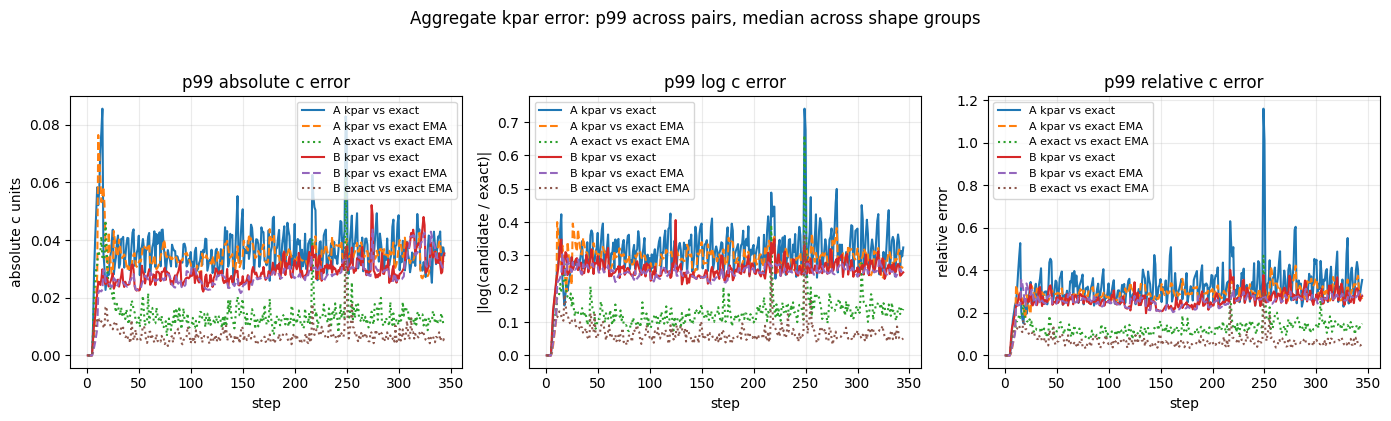

In [6]:
if agg.empty:
    fig, ax = plt.subplots(figsize=(8, 2.6))
    ax.text(0.5, 0.5, "No aggregate error records found", ha="center", va="center")
    ax.set_axis_off()
else:
    err_df = agg[(agg["step"] >= 1) & (agg["n"] == agg["n"].max())].copy()
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
    for side, sub in err_df.groupby("side"):
        by_step = sub.groupby("step", as_index=False)[[
            "log_err_p99", "abs_err_p99", "rel_err_p99",
            "ema_ref_log_err_p99", "ema_ref_abs_err_p99", "ema_ref_rel_err_p99",
            "true_ema_log_err_p99", "true_ema_abs_err_p99", "true_ema_rel_err_p99",
        ]].median(numeric_only=True)
        axes[0].plot(by_step["step"], by_step["abs_err_p99"], label=f"{side} kpar vs exact")
        axes[0].plot(by_step["step"], by_step["ema_ref_abs_err_p99"], ls="--", label=f"{side} kpar vs exact EMA")
        axes[0].plot(by_step["step"], by_step["true_ema_abs_err_p99"], ls=":", label=f"{side} exact vs exact EMA")
        axes[1].plot(by_step["step"], by_step["log_err_p99"], label=f"{side} kpar vs exact")
        axes[1].plot(by_step["step"], by_step["ema_ref_log_err_p99"], ls="--", label=f"{side} kpar vs exact EMA")
        axes[1].plot(by_step["step"], by_step["true_ema_log_err_p99"], ls=":", label=f"{side} exact vs exact EMA")
        axes[2].plot(by_step["step"], by_step["rel_err_p99"], label=f"{side} kpar vs exact")
        axes[2].plot(by_step["step"], by_step["ema_ref_rel_err_p99"], ls="--", label=f"{side} kpar vs exact EMA")
        axes[2].plot(by_step["step"], by_step["true_ema_rel_err_p99"], ls=":", label=f"{side} exact vs exact EMA")
    titles = ["p99 absolute c error", "p99 log c error", "p99 relative c error"]
    for ax, title in zip(axes, titles):
        ax.set_title(title)
        ax.set_xlabel("step")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("absolute c units")
    axes[1].set_ylabel("|log(candidate / exact)|")
    axes[2].set_ylabel("relative error")
    fig.suptitle("Aggregate kpar error: p99 across pairs, median across shape groups", y=1.04)
    fig.tight_layout()
    plt.show()


In [7]:
missing = [p for p in (POLICY_CSV, CACHE_CSV, FAIL_CSV) if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing policy CSVs: " + ", ".join(str(p.relative_to(ROOT)) for p in missing)
    )

policy = pd.read_csv(POLICY_CSV)
cache = pd.read_csv(CACHE_CSV)
fail = pd.read_csv(FAIL_CSV)

CANDIDATE_ERROR_COLUMNS = {
    "bulk per-layer c": "log_err_sr",
    "exact group-median c": "log_err_exact_group_median",
    "bulk group-median c": "log_err_sr_group_median",
}

summary_rows = []
for label, col in CANDIDATE_ERROR_COLUMNS.items():
    vals = policy[col].dropna().to_numpy()
    summary_rows.append({
        "candidate": label,
        "median |log ratio|": np.median(vals),
        "median multiplicative error": np.exp(np.median(vals)),
        "p90 multiplicative error": np.exp(np.percentile(vals, 90)),
    })
summary = pd.DataFrame(summary_rows)
display(summary)


,candidate,median |log ratio|,median multiplicative error,p90 multiplicative error
0,bulk per-layer c,0.431885,1.540158,2.103863
1,exact group-median c,0.151173,1.163198,1.699300
2,bulk group-median c,0.418549,1.519755,2.431076


## Bulk stable-rank c and κ retuning

The bulk rule below uses the same requested target, $\kappa_{\rm bulk}=0.6$, as the exact oracle. On these snapshots that makes bulk c systematically larger than exact c. That does not rule out the bulk rule: increasing $\kappa_{\rm bulk}$ lowers the bulk c, so a retuned bulk target could compensate for the approximation bias.

The right panel asks a narrow calibration question: which $\kappa_{\rm bulk}$ makes bulk c closest to exact eigvalsh c at oracle target $\kappa=0.6$ on these snapshots? It is not a training result.


,series,kappa_bulk,median_log_error,median_multiplicative_error,p90_log_error
40,all,0.750,0.114570,1.121391,0.387293
281,r=256 A,0.740,0.110302,1.116615,0.392655
366,r=256 B,0.760,0.086107,1.089922,0.260415
128,r=64 A,0.785,0.156211,1.169073,0.453934
200,r=64 B,0.740,0.109564,1.115791,0.366834


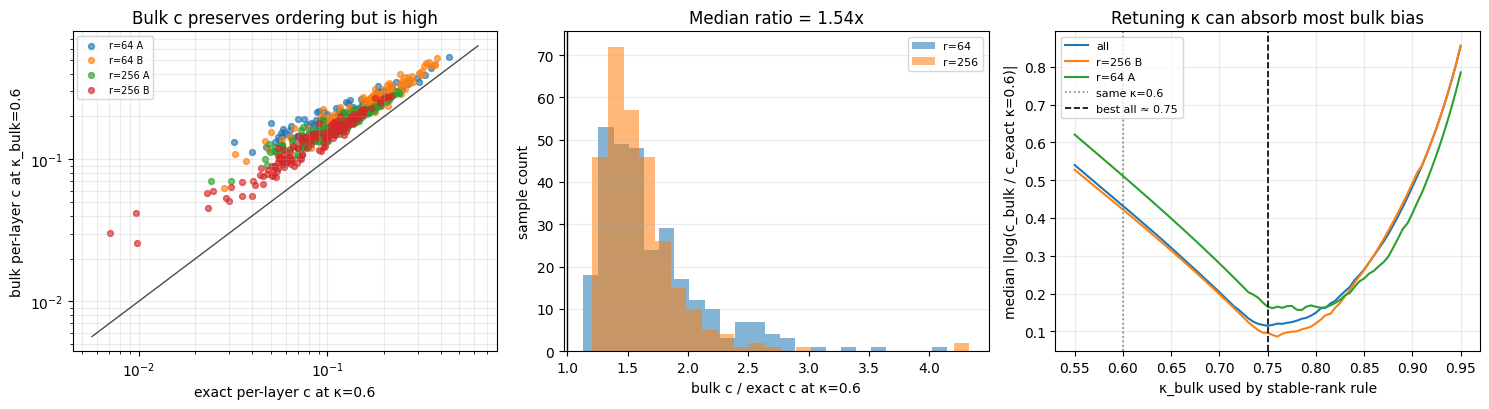

In [8]:
def c_sr_from_m_tail(m_tail, kappa, r, eps=1e-6, c_min=1e-3, c_max=1e3):
    m = np.clip(np.asarray(m_tail, dtype=float), eps, 1.0 - eps)
    r = np.asarray(r, dtype=float)
    k_tail = (r * float(kappa) - 1.0) / np.maximum(r - 1.0, 1.0)
    k_tail = np.clip(k_tail, eps, 1.0 - eps)
    c2 = m * (1.0 - k_tail) / np.maximum(k_tail - m, eps)
    c = np.sqrt(c2)
    c = np.clip(c, c_min, c_max)
    c = np.where(k_tail <= m + eps, c_max, c)
    c = np.where(k_tail >= 1.0 - eps, c_min, c)
    return c

kappa_grid = np.linspace(0.55, 0.95, 81)
tuning_rows = []
series_frames = [("all", policy)]
series_frames.extend(
    (f"r={r} {side}", group.copy())
    for (r, side), group in policy.groupby(["lora_r", "side"])
)
for label, sub in series_frames:
    for kappa_bulk in kappa_grid:
        c_candidate = c_sr_from_m_tail(sub["m_tail"], kappa_bulk, sub["r"])
        exact = sub["c_exact"].to_numpy()
        err = np.abs(np.log(np.maximum(c_candidate, 1e-30)) - np.log(exact))
        tuning_rows.append({
            "series": label,
            "kappa_bulk": kappa_bulk,
            "median_log_error": np.median(err),
            "p90_log_error": np.percentile(err, 90),
            "median_c_candidate": np.median(c_candidate),
        })
tuning = pd.DataFrame(tuning_rows)
best = tuning.loc[tuning.groupby("series")["median_log_error"].idxmin()].copy()
best["median_multiplicative_error"] = np.exp(best["median_log_error"])

display(best.sort_values("series")[[
    "series", "kappa_bulk", "median_log_error", "median_multiplicative_error", "p90_log_error"
]])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
for (rank, side), sub in policy.groupby(["lora_r", "side"]):
    ax.scatter(sub["c_exact"], sub["c_sr"], s=18, alpha=0.65, label=f"r={rank} {side}")
lo = min(policy["c_exact"].min(), policy["c_sr"].min()) * 0.8
hi = max(policy["c_exact"].max(), policy["c_sr"].max()) * 1.2
ax.plot([lo, hi], [lo, hi], color="black", lw=1, alpha=0.7)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("exact per-layer c at κ=0.6")
ax.set_ylabel("bulk per-layer c at κ_bulk=0.6")
ax.set_title("Bulk c preserves ordering but is high")
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=7)

ax = axes[1]
ratio = policy["c_sr"] / policy["c_exact"]
for rank, sub in policy.groupby("lora_r"):
    ax.hist((sub["c_sr"] / sub["c_exact"]), bins=24, alpha=0.55, label=f"r={rank}")
ax.axvline(1.0, color="black", lw=1)
ax.set_xlabel("bulk c / exact c at κ=0.6")
ax.set_ylabel("sample count")
ax.set_title(f"Median ratio = {np.median(ratio):.2f}x")
ax.grid(alpha=0.25, axis="y")
ax.legend(fontsize=8)

ax = axes[2]
for label, sub in tuning.groupby("series"):
    if label == "all" or label in {"r=64 A", "r=256 B"}:
        ax.plot(sub["kappa_bulk"], sub["median_log_error"], label=label)
all_best = best[best["series"] == "all"].iloc[0]
ax.axvline(0.6, color="gray", ls=":", lw=1.2, label="same κ=0.6")
ax.axvline(all_best["kappa_bulk"], color="black", ls="--", lw=1.2,
           label=f"best all ≈ {all_best['kappa_bulk']:.2f}")
ax.set_xlabel("κ_bulk used by stable-rank rule")
ax.set_ylabel("median |log(c_bulk / c_exact κ=0.6)|")
ax.set_title("Retuning κ can absorb most bulk bias")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


## Shared median c as an optimizer policy

This section measures the policy you described: use one shared c for a group instead of one c per layer. For each saved snapshot group, **exact group-median c** is the median of the exact per-layer c values in that group. Every layer in the group is then compared against its own exact per-layer c.

So `exact group-median c` answers: if the exact per-layer solves were available but the optimizer applied their median to every layer in the group, how much c mismatch would that create? `bulk group-median c` is the same idea using stable-rank bulk values as the input to the median.


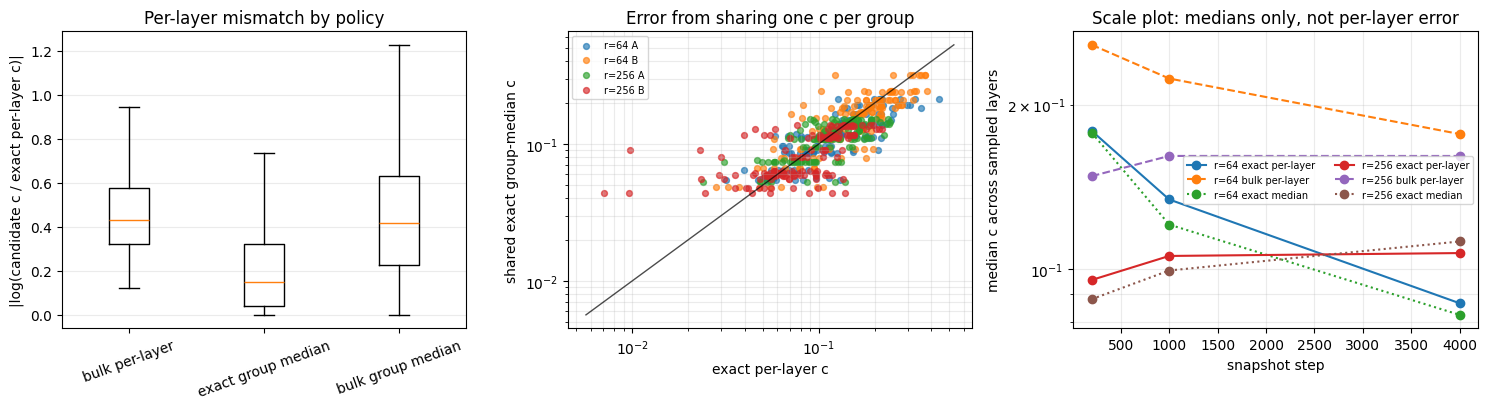

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
err_cols = [
    ("log_err_sr", "bulk per-layer"),
    ("log_err_exact_group_median", "exact group median"),
    ("log_err_sr_group_median", "bulk group median"),
]
values = [policy[col].dropna().to_numpy() for col, _ in err_cols]
ax.boxplot(values, tick_labels=[label for _, label in err_cols], showfliers=False)
ax.set_ylabel("|log(candidate c / exact per-layer c)|")
ax.set_title("Per-layer mismatch by policy")
ax.grid(alpha=0.25, axis="y")
ax.tick_params(axis="x", labelrotation=20)

ax = axes[1]
for (rank, side), sub in policy.groupby(["lora_r", "side"]):
    ax.scatter(sub["c_exact"], sub["c_exact_group_median"], s=18, alpha=0.65, label=f"r={rank} {side}")
lo = min(policy["c_exact"].min(), policy["c_exact_group_median"].min()) * 0.8
hi = max(policy["c_exact"].max(), policy["c_exact_group_median"].max()) * 1.2
ax.plot([lo, hi], [lo, hi], color="black", lw=1, alpha=0.7)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("exact per-layer c")
ax.set_ylabel("shared exact group-median c")
ax.set_title("Error from sharing one c per group")
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=7)

ax = axes[2]
by_step = policy.groupby(["lora_r", "step"], as_index=False)[[
    "c_exact", "c_sr", "c_exact_group_median", "c_sr_group_median",
]].median(numeric_only=True)
for rank, sub in by_step.groupby("lora_r"):
    ax.plot(sub["step"], sub["c_exact"], marker="o", label=f"r={rank} exact per-layer")
    ax.plot(sub["step"], sub["c_sr"], marker="o", ls="--", label=f"r={rank} bulk per-layer")
    ax.plot(sub["step"], sub["c_exact_group_median"], marker="o", ls=":", label=f"r={rank} exact median")
ax.set_yscale("log")
ax.set_xlabel("snapshot step")
ax.set_ylabel("median c across sampled layers")
ax.set_title("Scale plot: medians only, not per-layer error")
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=7, ncols=2)

fig.tight_layout()
plt.show()


## Kpar cache failure and simple stabilizers

The left plot is not a trajectory. It is the step-1750 optimizer cache, specifically the B-side n=0 cached c values that seed the kpar refresh. Each colored line is one shape group after sorting its cached c values from smallest to largest. The dashed line with the same color is that group's median.

The important feature is the bottom outlier: one cached c is around $10^{-19}$ while the rest of its group is around $10^{-2}$. A floor or a group-median policy would prevent that exact overflow path, but they are different policies: a floor is a hard numerical guard, while a group median deliberately removes per-layer c variation inside the group.


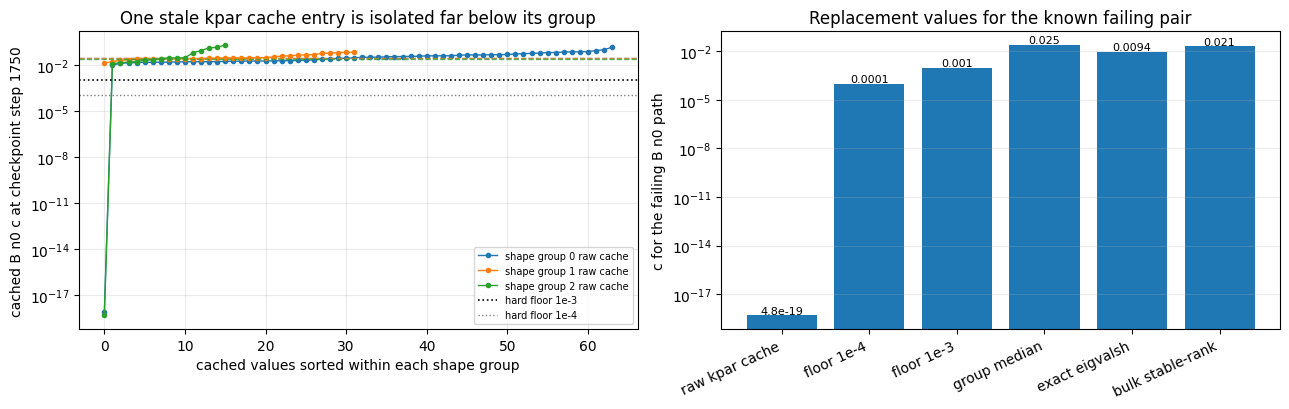

,group,local_index,c_raw,c_floor_1e_3,c_group_median,raw_over_median
135,0,7,8.108312e-19,0.001,0.027914,2.904701e-17
617,2,9,4.829003e-19,0.001,0.025202,1.916107e-17


,x_key,finite,c_used,c_exact,c_sr,log_err_used,log_err_sr
0,X_A_eff_n0,True,3.247215e-02,0.029506,0.042027,0.095804,0.353742
1,X_B_eff_n0,True,3.963888e-20,0.009387,0.020947,40.006088,0.802633
2,X_A_eff_n1,False,1.408965e-02,NaN,NaN,NaN,NaN
3,X_B_eff_n1,True,9.177268e-03,0.009162,0.020729,0.001626,0.816439


In [10]:
tiny = cache[(cache["slot"] == "ssc_c_cached_B_n0") & (cache["c_raw"] < 1e-6)].copy()
b_fail = fail[(fail["x_key"] == "X_B_eff_n0") & (fail["finite"] == True)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
for group, sub in cache[cache["slot"] == "ssc_c_cached_B_n0"].groupby("group"):
    ordered = sub.sort_values("c_raw").reset_index(drop=True)
    line = ax.plot(
        np.arange(len(ordered)), ordered["c_raw"].clip(lower=1e-30),
        marker="o", ms=3, lw=1, label=f"shape group {group} raw cache",
    )[0]
    ax.axhline(
        ordered["c_group_median"].iloc[0], color=line.get_color(),
        ls="--", lw=1, alpha=0.75,
    )
ax.axhline(1e-3, color="black", ls=":", lw=1.2, label="hard floor 1e-3")
ax.axhline(1e-4, color="gray", ls=":", lw=1.0, label="hard floor 1e-4")
ax.set_yscale("log")
ax.set_xlabel("cached values sorted within each shape group")
ax.set_ylabel("cached B n0 c at checkpoint step 1750")
ax.set_title("One stale kpar cache entry is isolated far below its group")
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=7)

ax = axes[1]
if not tiny.empty and not b_fail.empty:
    target = tiny.sort_values("c_raw").iloc[0]
    match = tiny[(tiny["group"] == 2) & (tiny["local_index"] == 9)]
    if not match.empty:
        target = match.iloc[0]
    b = b_fail.iloc[0]
    bars = pd.Series({
        "raw kpar cache": target["c_raw"],
        "floor 1e-4": target["c_floor_1e_4"],
        "floor 1e-3": target["c_floor_1e_3"],
        "group median": target["c_group_median"],
        "exact eigvalsh": b["c_exact"],
        "bulk stable-rank": b["c_sr"],
    })
    ax.bar(np.arange(len(bars)), bars.to_numpy())
    ax.set_xticks(np.arange(len(bars)))
    ax.set_xticklabels(bars.index, rotation=25, ha="right")
    ax.set_yscale("log")
    ax.set_ylabel("c for the failing B n0 path")
    ax.set_title("Replacement values for the known failing pair")
    for i, value in enumerate(bars.to_numpy()):
        ax.text(i, value * 1.25, f"{value:.2g}", ha="center", fontsize=8)
    ax.grid(alpha=0.25, axis="y", which="both")
else:
    ax.text(0.5, 0.5, "No tiny cached-c rows found", ha="center", va="center")
    ax.set_axis_off()
fig.tight_layout()
plt.show()

if not tiny.empty:
    display(tiny[["group", "local_index", "c_raw", "c_floor_1e_3", "c_group_median", "raw_over_median"]])
display(fail[["x_key", "finite", "c_used", "c_exact", "c_sr", "log_err_used", "log_err_sr"]])
